# Text Classification - 5-Phase Hierarchical Pipeline

**Goal:** Classify texts based on their origin (human-written vs AI-generated, and which AI).

**Evaluation metric:** Macro F1 Score

**Architecture:** 5-phase binary cascade - each phase peels off one class:
- Phase 1: Human (0) vs AI (1,2,3,4,5)
- Phase 2: Label 4 vs (1,2,3,5)
- Phase 3: Label 3 vs (1,2,5)
- Phase 4: Label 5 vs (1,2)
- Phase 5: Label 1 vs Label 2

## 0. Imports and Global Seed

In [ ]:
import os, random, warnings, json
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# NLP
import nltk
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag

# Sklearn
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler

# LightGBM (optional, for some submissions)
try:
    from lightgbm import LGBMClassifier
    HAS_LGBM = True
except ImportError:
    HAS_LGBM = False
    print('WARNING: lightgbm not installed, LGBMClassifier submissions will fail')

from scipy.stats import mode as scipy_mode

# UMAP
import umap

# Sparse
from scipy.sparse import hstack, csr_matrix

warnings.filterwarnings("ignore")

SEED = 359956
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

for res in ["punkt", "punkt_tab", "wordnet", "stopwords", #for reproducibility
            "averaged_perceptron_tagger", "averaged_perceptron_tagger_eng"]:
    nltk.download(res, quiet=True)


c:\Users\simop\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Data Loading

In [ ]:
DATA_PATH = "train.csv"
df = pd.read_csv(DATA_PATH)
print(f"Loaded {len(df)} rows | columns: {list(df.columns)}")
print(df["LABEL"].value_counts().sort_index())

df = df.dropna(subset=["TEXT", "LABEL"]).reset_index(drop=True)
print(f"After dropna: {len(df)} rows")

Loaded 2400 rows | columns: ['TEXT', 'LABEL']
LABEL
0    1520
1      80
2     160
3      80
4     240
5     320
Name: count, dtype: int64
After dropna: 2400 rows


## 2. NLP Setup

Lemmatization only, **no stopword removal**.

In [4]:
lemmatizer = WordNetLemmatizer()

def clean_text_none(text):
    """Lemmatize only - no stopword removal. Best config from tuning."""
    text = str(text).lower()
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t.isalpha()]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return " ".join(tokens)

print("Cleaning texts ")
df["text_clean"] = df["TEXT"].apply(clean_text_none)
print("Done.")



Cleaning texts 
Done.


## 3. Exploratory Data Analysis


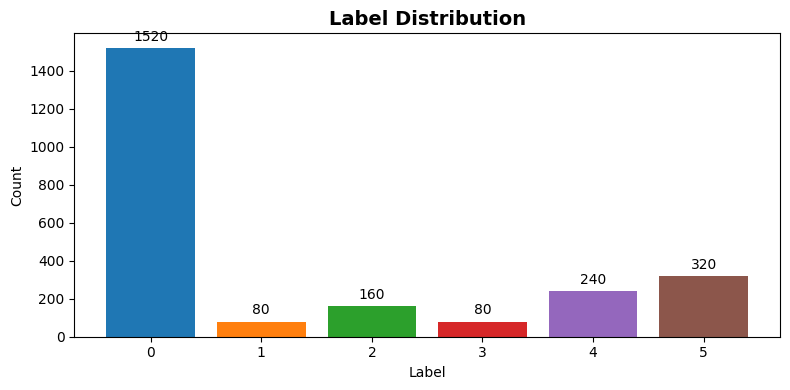

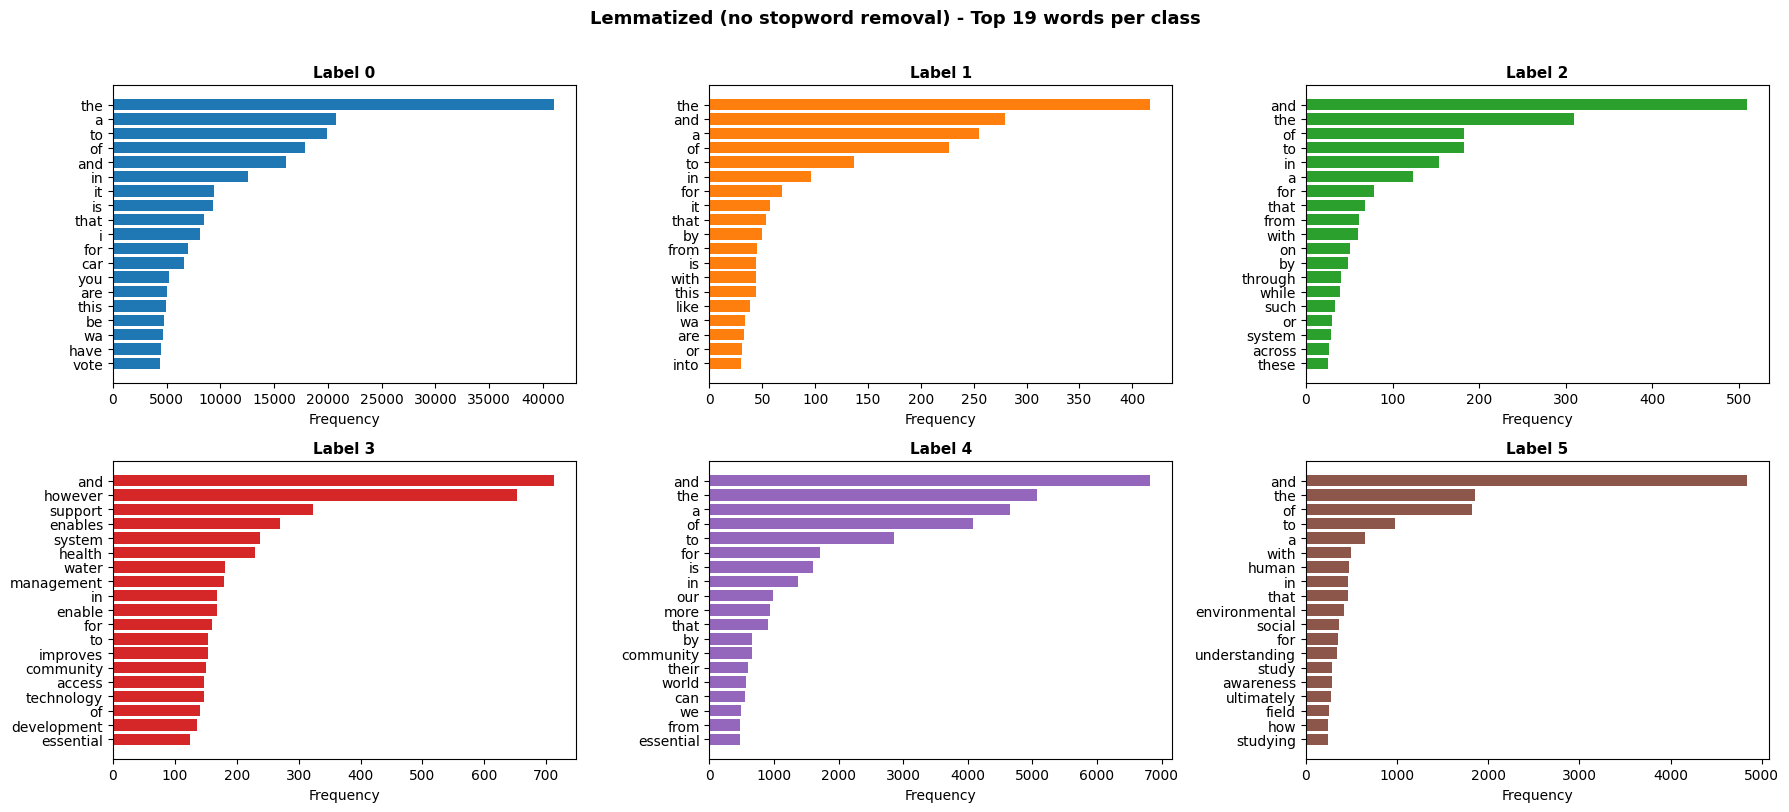

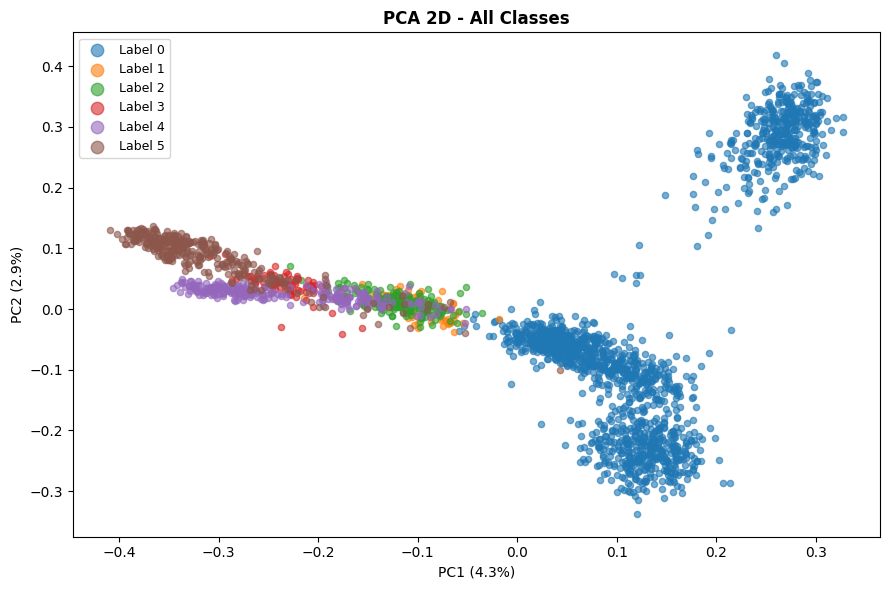

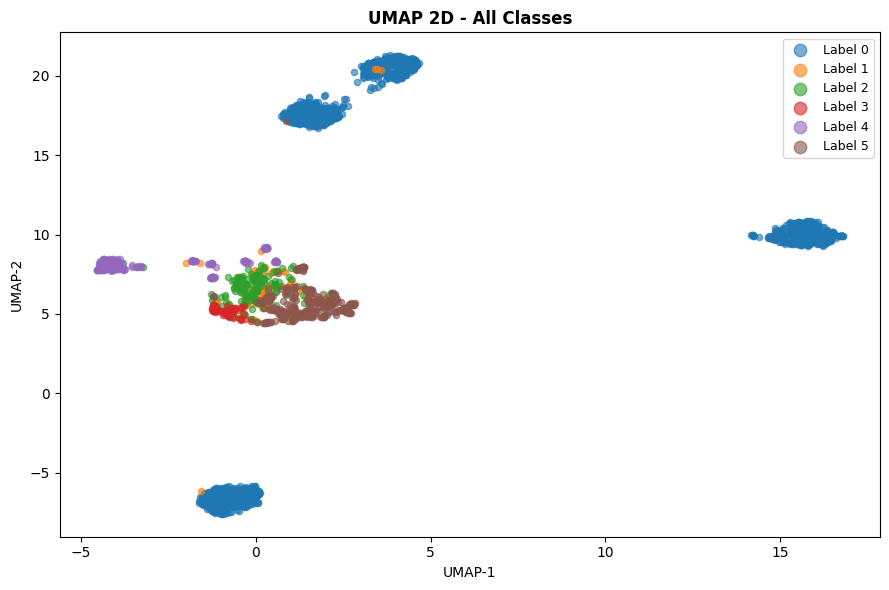

In [5]:
# ── 3a. Label distribution ────────────────────────────────────
label_counts = df["LABEL"].value_counts().sort_index()
n_classes = len(label_counts)
palette = sns.color_palette("tab10", n_classes)

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.bar(label_counts.index.astype(str), label_counts.values, color=palette)
ax.bar_label(bars, padding=3)
ax.set_title("Label Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Label")
ax.set_ylabel("Count")
plt.tight_layout()
plt.show()

# ── 3b. Top-N most frequent words per class ───────────────────
TOP_N = 19

def plot_top_words(df_in, text_col, label_col, top_n, title_prefix):
    labels = sorted(df_in[label_col].unique())
    cols = 3
    rows = (len(labels) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 6, rows * 4))
    axes = axes.flatten()
    for idx, lbl in enumerate(labels):
        subset = df_in[df_in[label_col] == lbl][text_col]
        all_words = " ".join(subset).split()
        counter = Counter(all_words).most_common(top_n)
        words, counts = zip(*counter) if counter else ([], [])
        ax = axes[idx]
        ax.barh(list(words)[::-1], list(counts)[::-1],
                color=palette[idx % len(palette)])
        ax.set_title(f"Label {lbl}", fontsize=11, fontweight="bold")
        ax.set_xlabel("Frequency")
    for j in range(len(labels), len(axes)):
        axes[j].set_visible(False)
    fig.suptitle(f"{title_prefix} - Top {top_n} words per class",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.show()

plot_top_words(df, "text_clean", "LABEL", TOP_N,
               title_prefix="Lemmatized (no stopword removal)")

# ── 3c. PCA & UMAP - all classes ─────────────────────────────
def plot_dim_reduction_global(texts, labels, title, method="pca"):
    tfidf = TfidfVectorizer(max_features=5000, sublinear_tf=True,
                            ngram_range=(1, 2), min_df=2)
    X = tfidf.fit_transform(texts)
    if method == "pca":
        reducer = PCA(n_components=2, random_state=SEED)
        coords = reducer.fit_transform(X.toarray())
        var = reducer.explained_variance_ratio_
        ax_lbl = (f"PC1 ({var[0]*100:.1f}%)", f"PC2 ({var[1]*100:.1f}%)")
    else:
        reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
        coords = reducer.fit_transform(X)
        ax_lbl = ("UMAP-1", "UMAP-2")
    fig, ax = plt.subplots(figsize=(9, 6))
    for i, lbl in enumerate(sorted(labels.unique())):
        mask = labels == lbl
        ax.scatter(coords[mask, 0], coords[mask, 1], label=f"Label {lbl}",
                   color=palette[i % len(palette)], alpha=0.6, s=20)
    ax.set_xlabel(ax_lbl[0]); ax.set_ylabel(ax_lbl[1])
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(markerscale=2, fontsize=9, loc="best")
    plt.tight_layout()
    plt.show()

plot_dim_reduction_global(df["text_clean"], df["LABEL"], "PCA 2D - All Classes", "pca")
plot_dim_reduction_global(df["text_clean"], df["LABEL"], "UMAP 2D - All Classes", "umap")



## 4. Modelling - 5-Phase Pipeline

### 4a. Load Model Configuration

Parameters are loaded from a JSON specifics file. Change **SUBMISSION** to evaluate any saved configuration.
Submission 1 doesn't work with this code, because the model for the phase 5 isn't a HistGB.

In [6]:
SUBMISSION = 4  #start from 2
SUBMISSION_FILE = f"submissions/submission{SUBMISSION}_specifics.json"

with open(SUBMISSION_FILE, "r") as fp:
    spec_raw = json.load(fp)

sub_key = list(spec_raw.keys())[0]
SPEC = spec_raw[sub_key]

IS_ENSEMBLE = SPEC.get("pipeline", "") == "ensemble"

if IS_ENSEMBLE:
    ENSEMBLE_TYPE = SPEC["ensemble_type"]
    ENSEMBLE_MEMBERS = SPEC["members"]
    ENSEMBLE_PRIORITY = SPEC.get("priority")
    print(f"Loaded ENSEMBLE config: {sub_key}")
    print(f"  Type: {ENSEMBLE_TYPE}")
    print(f"  Members: {ENSEMBLE_MEMBERS}")
    if ENSEMBLE_PRIORITY:
        print(f"  Priority (tie-break): {ENSEMBLE_PRIORITY}")
    # Load all member specs
    MEMBER_SPECS = {}
    for mname in ENSEMBLE_MEMBERS:
        mfile = f"submissions/{mname}_specifics.json"
        with open(mfile) as f:
            mraw = json.load(f)
        mkey = list(mraw.keys())[0]
        MEMBER_SPECS[mname] = mraw[mkey]
        print(f"    Loaded {mname} from {mfile}")
else:
    print(f"Loaded config: {sub_key}")
    for metric_key in ["cv_f1_macro_10fold", "cv_f1_optuna", "cv_f1_e2e_3fold",
                        "cv_f1_p5_loocv"]:
        v = SPEC.get(metric_key)
        if v is not None:
            print(f"  {metric_key}: {v}")

    p14 = SPEC["phases_1_to_4"]
    p14_params = p14["params"]

    if "C" in p14_params:
        print(f"  Phases 1-4: {p14['model']}, C={p14_params['C']}")
    else:
        c_str = ", ".join(f"p{i}={p14_params.get(f'C_p{i}', '?'):.4f}" for i in range(1,5))
        print(f"  Phases 1-4: {p14['model']}, per-phase C: {c_str}")
    print(f"  P14 mode={p14.get('mode','shared')}, voting={p14.get('voting', False)}")
    print(f"  Phase 5: {SPEC['phase_5']['model']} on {SPEC['phase_5']['features']}")
    print(f"  P5 voting={SPEC['phase_5'].get('voting', False)}")



Loaded config: submission4
  cv_f1_macro_10fold: 0.9567
  Phases 1-4: LinearSVC, C=6.4099
  P14 mode=shared, voting=False
  Phase 5: HistGradientBoostingClassifier on ImpCHI (Improved Chi-squared, top-K per class) + stylometric (30 features)
  P5 voting=False


# 4b. Feature Extraction Functions

**Stylometric features** (30 dimensions): capture *how* text is written - punctuation rates, POS tag percentages, sentence/word length stats, TTR, etc.

**ImpCHI (Improved Chi-squared)**: selects the top-K most discriminative words *per class* (not globally), then takes the union. This prevents the majority class from drowning out the minority class's vocabulary.


In [7]:
def extract_stylometric(text):
    text = str(text)
    sentences = sent_tokenize(text)
    n_sentences = max(len(sentences), 1)
    sent_lengths = [len(word_tokenize(s)) for s in sentences]
    words = word_tokenize(text)
    alpha_words = [w for w in words if w.isalpha()]
    n_words = max(len(alpha_words), 1)
    word_lengths = [len(w) for w in alpha_words] if alpha_words else [0]
    n_chars = max(len(text), 1)
    n_commas=text.count(",")
    n_periods=text.count(".")
    n_exclaim=text.count("!")
    n_question=text.count("?")
    n_semicolon=text.count(";")
    n_colon=text.count(":")
    n_dash=text.count("\u2014")+text.count("-")
    n_parens=text.count("(")+text.count(")")
    n_quotes=text.count('"')+text.count("'")+text.count("\u201c")+text.count("\u201d")
    try:
        tags = pos_tag(alpha_words[:200])
        tc = Counter(t for _,t in tags); nt = max(sum(tc.values()),1)
        pn=(tc.get("NN",0)+tc.get("NNS",0)+tc.get("NNP",0)+tc.get("NNPS",0))/nt
        pv=(tc.get("VB",0)+tc.get("VBD",0)+tc.get("VBG",0)+tc.get("VBN",0)+tc.get("VBP",0)+tc.get("VBZ",0))/nt
        pa=(tc.get("JJ",0)+tc.get("JJR",0)+tc.get("JJS",0))/nt
        pd=(tc.get("RB",0)+tc.get("RBR",0)+tc.get("RBS",0))/nt
    except: pn=pv=pa=pd=0.0
    uw=set(w.lower() for w in alpha_words); ttr=len(uw)/n_words
    ps=sum(1 for w in alpha_words if len(w)<=3)/n_words
    pl=sum(1 for w in alpha_words if len(w)>=8)/n_words
    return {"n_chars":n_chars,"n_words":n_words,"n_sentences":n_sentences,
            "avg_word_len":np.mean(word_lengths),"std_word_len":np.std(word_lengths),
            "avg_sent_len":np.mean(sent_lengths),
            "std_sent_len":np.std(sent_lengths) if len(sent_lengths)>1 else 0,
            "max_sent_len":max(sent_lengths),"min_sent_len":min(sent_lengths),
            "comma_rate":n_commas/n_words,"period_rate":n_periods/n_words,
            "exclaim_rate":n_exclaim/n_words,"question_rate":n_question/n_words,
            "semicolon_rate":n_semicolon/n_words,"colon_rate":n_colon/n_words,
            "dash_rate":n_dash/n_words,"paren_rate":n_parens/n_words,
            "quote_rate":n_quotes/n_words,
            "total_punct_rate":(n_commas+n_periods+n_exclaim+n_question+n_semicolon+n_colon)/n_words,
            "pct_noun":pn,"pct_verb":pv,"pct_adj":pa,"pct_adv":pd,
            "noun_verb_ratio":pn/max(pv,0.001),
            "ttr":ttr,"pct_short_words":ps,"pct_long_words":pl,
            "words_per_sentence":n_words/n_sentences,"chars_per_word":n_chars/n_words}


# ── Stylometric feature group indices for subset selection ────
STYLO_GROUPS = {
    "all_30":          list(range(29)),
    "punctuation":     list(range(9, 19)),
    "pos":             list(range(19, 24)),
    "length":          list(range(0, 9)),
    "vocabulary":      list(range(24, 27)),
    "structure":       [27, 28],
    "punct_pos":       list(range(9, 24)),
    "punct_pos_vocab": list(range(9, 24)) + list(range(24, 27)),
    "no_length":       list(range(9, 29)),
    "no_pos":          list(range(0, 19)) + list(range(24, 29)),
}

stylo_all = pd.DataFrame(df["TEXT"].apply(extract_stylometric).tolist()).values.astype(float)
print(f"Stylometric features: {stylo_all.shape}")

def build_impchi(X_tr_text, X_val_text, y_tr, k_per_class,
                 impchi_max_feat=15000, impchi_ngram=(1,2), impchi_min_df=2,
                 impchi_sublinear=True):
    #Improved Chi-squared: select top-K features per class, then union.
    tfidf = TfidfVectorizer(max_features=impchi_max_feat, ngram_range=impchi_ngram,
                            sublinear_tf=impchi_sublinear, min_df=impchi_min_df,
                            strip_accents="unicode", analyzer="word")
    X_tr_full = tfidf.fit_transform(X_tr_text)
    X_val_full = tfidf.transform(X_val_text)
    selected = set()
    for cls in np.unique(y_tr):
        scores, _ = chi2(X_tr_full, (y_tr == cls).astype(int))
        selected.update(np.argsort(scores)[-k_per_class:])
    sel = sorted(selected)
    return X_tr_full[:, sel], X_val_full[:, sel], tfidf, sel

Stylometric features: (2400, 29)


## 4c. Train / Validation Split (80/20)

In [8]:
train_idx, val_idx = train_test_split(
    np.arange(len(df)), test_size=0.20, random_state=SEED, stratify=df["LABEL"])
print(f"Train: {len(train_idx)} | Val: {len(val_idx)}")

texts_clean = df["text_clean"].values
texts_raw = df["TEXT"].values
all_labels = df["LABEL"].values
y_tr_full = all_labels[train_idx]
y_val_full = all_labels[val_idx]

if not IS_ENSEMBLE:
    # ── TF-IDF for Phases 1-4 (same params for all four phases) ──
    p14 = SPEC["phases_1_to_4"]
    tfidf_p = p14["tfidf"]
    p14_params = p14["params"]

    tfidf_model = TfidfVectorizer(
        max_features=tfidf_p["max_features"],
        ngram_range=tuple(tfidf_p["ngram_range"]),
        sublinear_tf=tfidf_p["sublinear_tf"],
        min_df=tfidf_p["min_df"],
        strip_accents="unicode", analyzer="word")
    X_tr_tfidf = tfidf_model.fit_transform(texts_clean[train_idx])
    X_val_tfidf = tfidf_model.transform(texts_clean[val_idx])
    print(f"TF-IDF shape: {X_tr_tfidf.shape}")

    # ── Helpers for per-phase C and voting ────────────────────────
    P14_VOTING = p14.get("voting", False)

    def get_svc_C(phase_num, view="main"):
        if view == "main":
            return p14_params.get(f"C_p{phase_num}", p14_params.get("C"))
        else:
            return p14_params.get(f"C_{view}_p{phase_num}",
                                  p14_params.get(f"C_{view}"))

    def make_svc(C_val):
        cw = p14_params.get("class_weight", "balanced")
        return LinearSVC(C=C_val, max_iter=p14_params.get("max_iter", 3000),
                         class_weight=cw, random_state=SEED)

    def majority_vote(preds_list):
        stacked = np.stack(preds_list, axis=0)
        result = scipy_mode(stacked, axis=0, keepdims=False)
        return np.asarray(result.mode).ravel()

    def train_and_predict_phase(phase_num, X_tr, y_tr, X_val):
        views = ["main"]
        if P14_VOTING:
            for v in ["v2", "v3"]:
                if get_svc_C(phase_num, v) is not None:
                    views.append(v)
        preds = []
        for view in views:
            C_val = get_svc_C(phase_num, view)
            m = make_svc(C_val)
            m.fit(X_tr, y_tr)
            preds.append(m.predict(X_val))
        if len(preds) > 1:
            return majority_vote(preds)
        return preds[0]

    svc_C = get_svc_C(1, "main")
else:
    # Ensemble: define majority_vote here (used by ensemble cell)
    def majority_vote(preds_list):
        stacked = np.stack(preds_list, axis=0)
        result = scipy_mode(stacked, axis=0, keepdims=False)
        return np.asarray(result.mode).ravel()
    print("Ensemble mode — skipping single-pipeline TF-IDF setup")



Train: 1920 | Val: 480
TF-IDF shape: (1920, 5272)


### Plot helpers


In [9]:
def plot_cm(y_true, y_pred, lbls, title):
    cm = confusion_matrix(y_true, y_pred, labels=lbls)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm_pct, annot=True, fmt=".1f", cmap="Blues",
                xticklabels=lbls, yticklabels=lbls, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title, fontweight="bold", fontsize=10)
    plt.tight_layout()
    plt.show()

def plot_pca_umap(X_sparse, labels, label_list, title_prefix, colors=None):
    X_dense = X_sparse.toarray() if hasattr(X_sparse, "toarray") else X_sparse
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    pca = PCA(n_components=2, random_state=SEED)
    cp = pca.fit_transform(X_dense); var = pca.explained_variance_ratio_
    for lbl in label_list:
        m = labels == lbl; c = colors[lbl] if colors else None
        axes[0].scatter(cp[m,0], cp[m,1], label=f"{lbl}", color=c, alpha=0.6, s=25)
    axes[0].set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
    axes[0].set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
    axes[0].set_title(f"PCA - {title_prefix}", fontweight="bold")
    axes[0].legend(fontsize=8)
    reducer = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
    cu = reducer.fit_transform(X_dense)
    for lbl in label_list:
        m = labels == lbl
        c = colors[lbl] if colors else None
        axes[1].scatter(cu[m,0], cu[m,1], label=f"{lbl}", color=c, alpha=0.6, s=25)
    axes[1].set_xlabel("UMAP-1")
    axes[1].set_ylabel("UMAP-2")
    axes[1].set_title(f"UMAP - {title_prefix}", fontweight="bold"); axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

### 4d. Phase 1 - Human (0) vs AI (1,2,3,4,5)


Phase 1 - F1 macro: 0.9978


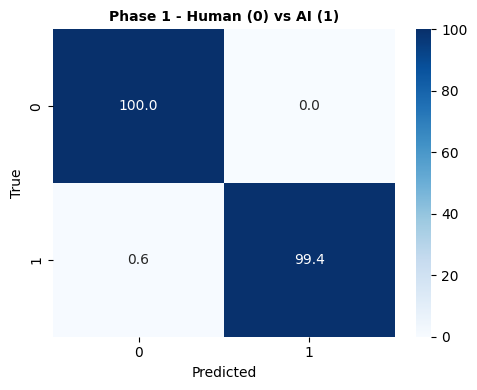

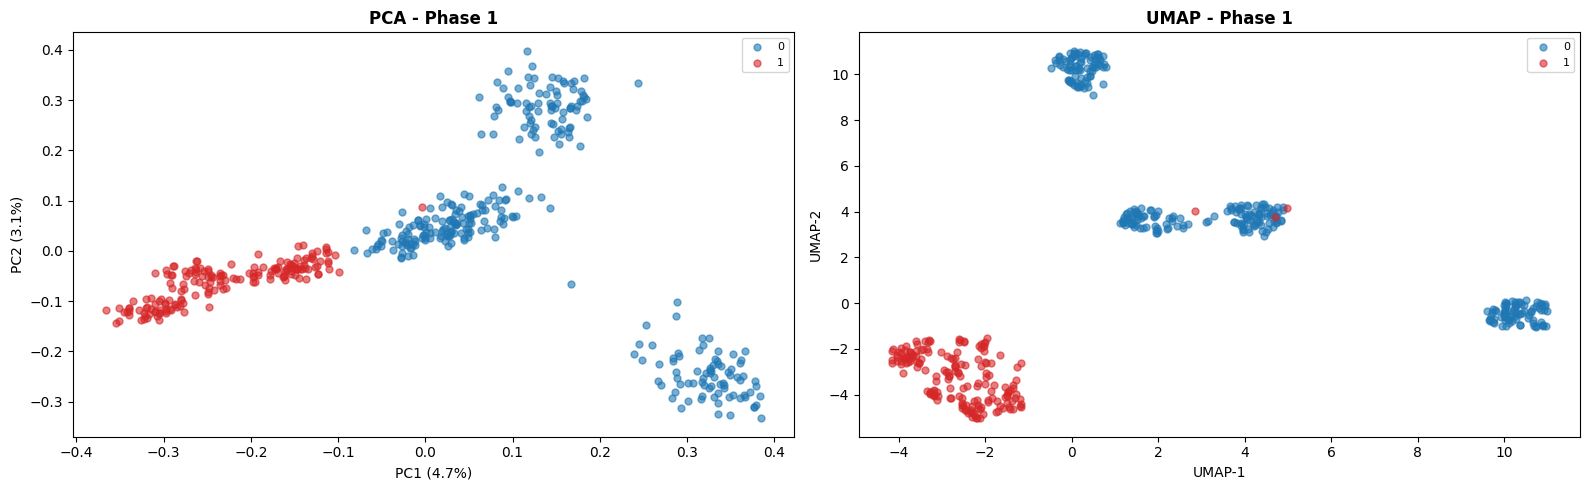

In [10]:
if IS_ENSEMBLE:
    print("Ensemble mode — skipping (see ensemble cell below)")
else:
    y_tr_p1 = (y_tr_full != 0).astype(int)
    y_val_p1 = (y_val_full != 0).astype(int)

    pred_p1 = train_and_predict_phase(1, X_tr_tfidf, y_tr_p1, X_val_tfidf)
    f1_p1 = f1_score(y_val_p1, pred_p1, average="macro")
    print(f"Phase 1 - F1 macro: {f1_p1:.4f}")

    plot_cm(y_val_p1, pred_p1, [0, 1], "Phase 1 - Human (0) vs AI (1)")
    plot_pca_umap(X_val_tfidf, y_val_p1, [0, 1], "Phase 1",
                  colors={0: "tab:blue", 1: "tab:red"})

    val_pos = np.arange(len(y_val_full))
    final_pred = np.full(len(y_val_full), -1, dtype=int)
    final_pred[pred_p1 == 0] = 0
    ai_pos = val_pos[pred_p1 == 1]




### 4e. Phase 2 - Label 4 vs (1,2,3,5)


Phase 2 - F1 macro: 1.0000


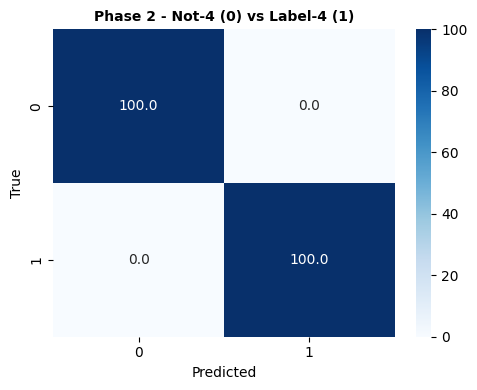

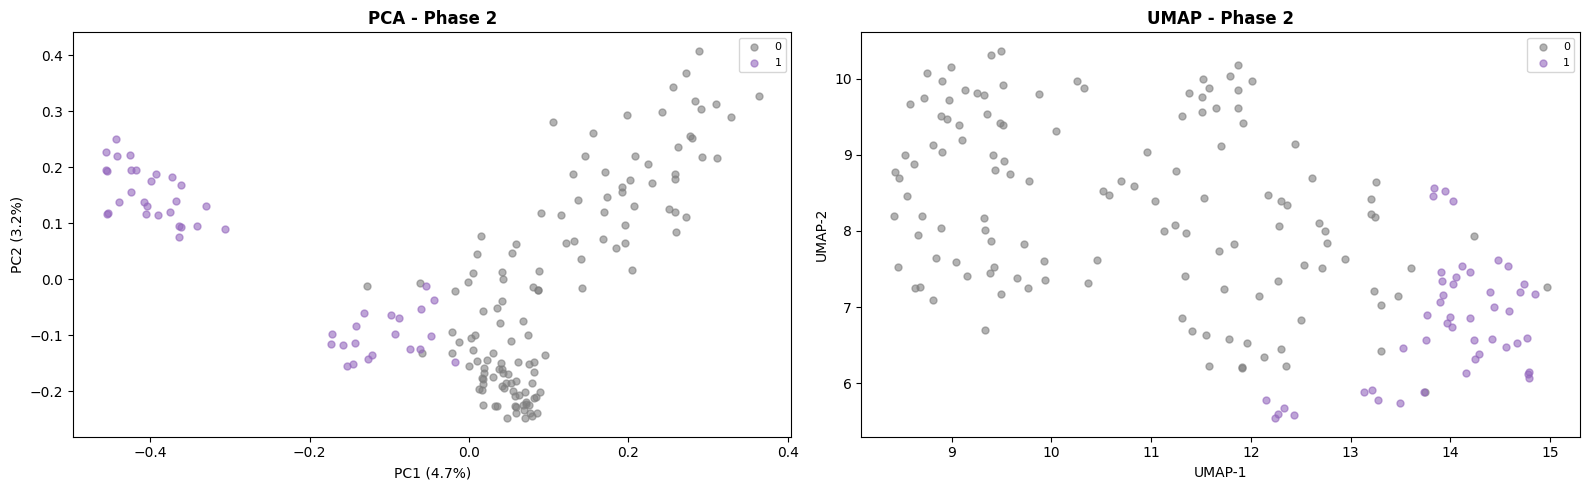

In [ ]:
if IS_ENSEMBLE:
    print("Ensemble mode — skipping (see ensemble cell below)")
else:
    ai_mask_tr = y_tr_full != 0
    pred_p2 = train_and_predict_phase(
        2, X_tr_tfidf[ai_mask_tr], (y_tr_full[ai_mask_tr] == 4).astype(int),
        X_val_tfidf[ai_pos])

    y_val_p2 = (y_val_full[ai_pos] == 4).astype(int)
    f1_p2 = f1_score(y_val_p2, pred_p2, average="macro")
    print(f"Phase 2 - F1 macro: {f1_p2:.4f}")

    plot_cm(y_val_p2, pred_p2, [0, 1], "Phase 2 - Not-4 (0) vs Label-4 (1)")
    plot_pca_umap(X_val_tfidf[ai_pos], y_val_p2, [0, 1], "Phase 2",
                  colors={0: "tab:gray", 1: "tab:purple"})

    is_4 = pred_p2 == 1
    final_pred[ai_pos[is_4]] = 4
    remaining = ai_pos[~is_4]

### 4f. Phase 3 - Label 3 vs (1,2,5)


Phase 3 - F1 macro: 1.0000


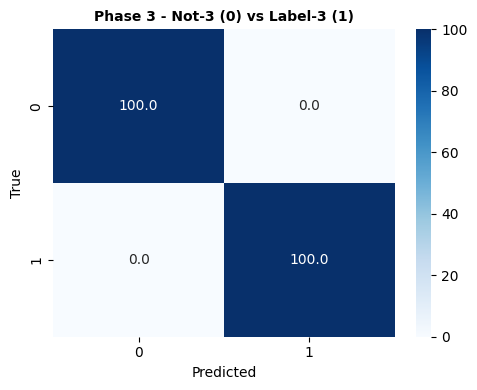

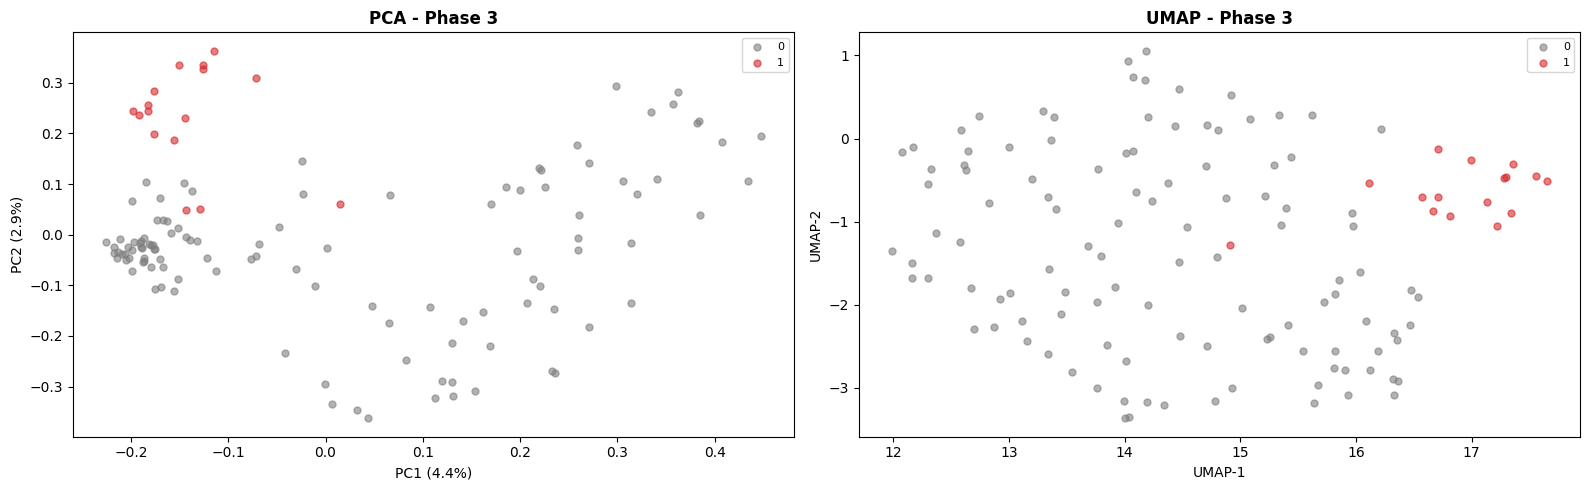

In [ ]:
if IS_ENSEMBLE:
    print("Ensemble mode — skipping (see ensemble cell below)")
else:
    mask_1235 = np.isin(y_tr_full, [1, 2, 3, 5])
    pred_p3 = train_and_predict_phase(
        3, X_tr_tfidf[mask_1235], (y_tr_full[mask_1235] == 3).astype(int),
        X_val_tfidf[remaining])

    y_val_p3 = (y_val_full[remaining] == 3).astype(int)
    f1_p3 = f1_score(y_val_p3, pred_p3, average="macro")
    print(f"Phase 3 - F1 macro: {f1_p3:.4f}")

    plot_cm(y_val_p3, pred_p3, [0, 1], "Phase 3 - Not-3 (0) vs Label-3 (1)")
    plot_pca_umap(X_val_tfidf[remaining], y_val_p3, [0, 1], "Phase 3",
                  colors={0: "tab:gray", 1: "tab:red"})

    is_3 = pred_p3 == 1
    final_pred[remaining[is_3]] = 3
    remaining = remaining[~is_3]

### 4g. Phase 4 - Label 5 vs (1,2)


Phase 4 - F1 macro: 1.0000


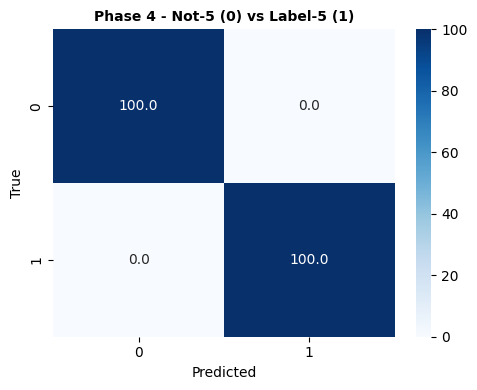

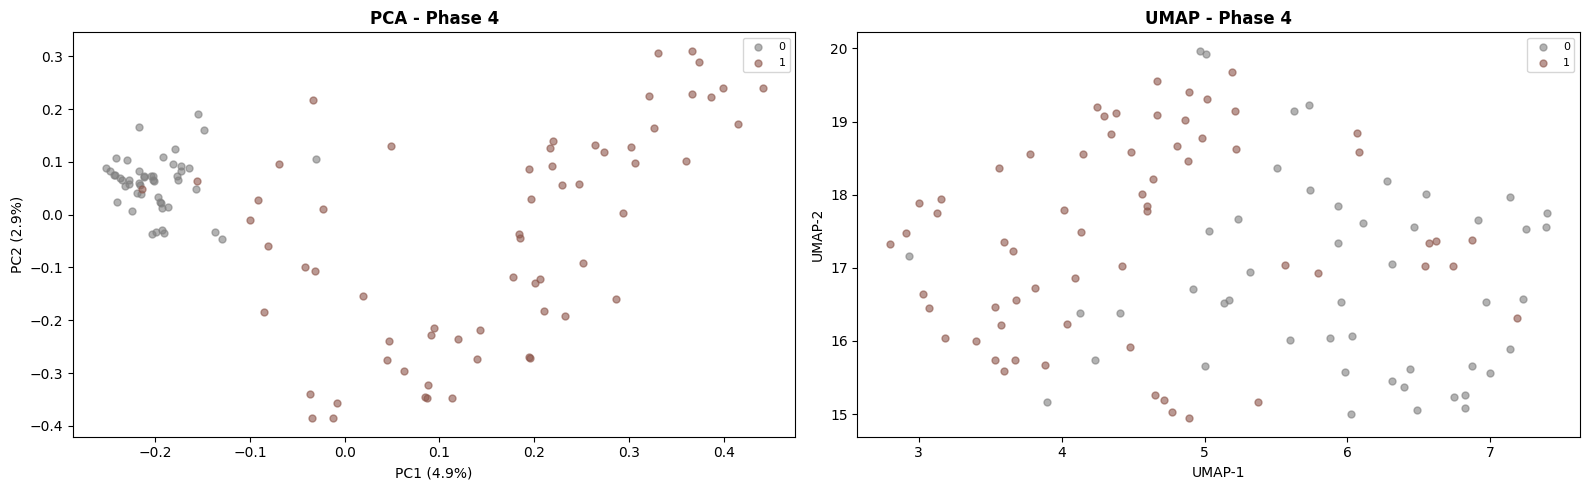

In [ ]:
if IS_ENSEMBLE:
    print("Ensemble mode — skipping (see ensemble cell below)")
else:
    mask_125 = np.isin(y_tr_full, [1, 2, 5])
    pred_p4 = train_and_predict_phase(
        4, X_tr_tfidf[mask_125], (y_tr_full[mask_125] == 5).astype(int),
        X_val_tfidf[remaining])

    y_val_p4 = (y_val_full[remaining] == 5).astype(int)
    f1_p4 = f1_score(y_val_p4, pred_p4, average="macro")
    print(f"Phase 4 - F1 macro: {f1_p4:.4f}")

    plot_cm(y_val_p4, pred_p4, [0, 1], "Phase 4 - Not-5 (0) vs Label-5 (1)")
    plot_pca_umap(X_val_tfidf[remaining], y_val_p4, [0, 1], "Phase 4",
                  colors={0: "tab:gray", 1: "tab:brown"})

    is_5 = pred_p4 == 1
    final_pred[remaining[is_5]] = 5
    remaining = remaining[~is_5]


### 4h. Phase 5 - Label 1 vs Label 2

Uses **ImpCHI + stylometric features** with **HistGradientBoostingClassifier**.
ImpCHI selects discriminative words per class, ensuring Label 1's specific vocabulary is not overwhelmed by Label 2 (which has 2x more samples).


Stylo subset: all_30 (29 features)
Phase 5 features: 93 (ImpCHI + 29 stylo)
Phase 5 train: 192 | val: 48
Phase 5 model: HistGradientBoostingClassifier, voting=False

Phase 5 - F1 macro: 0.8634


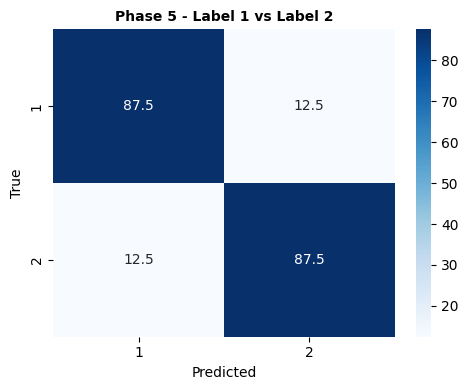

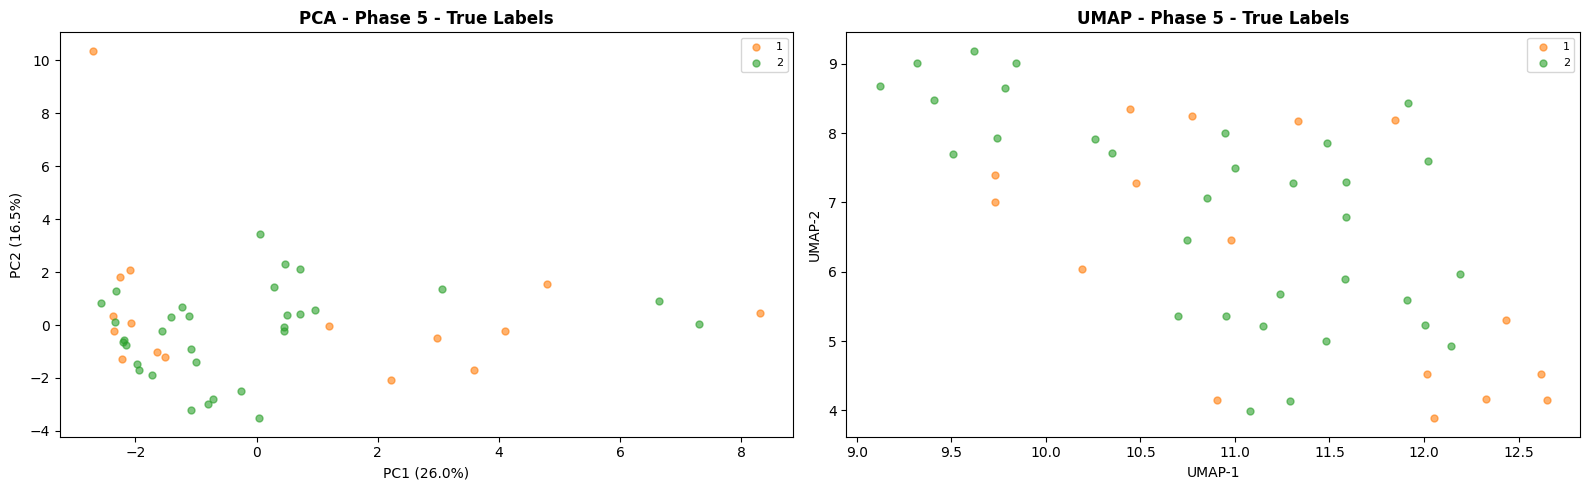

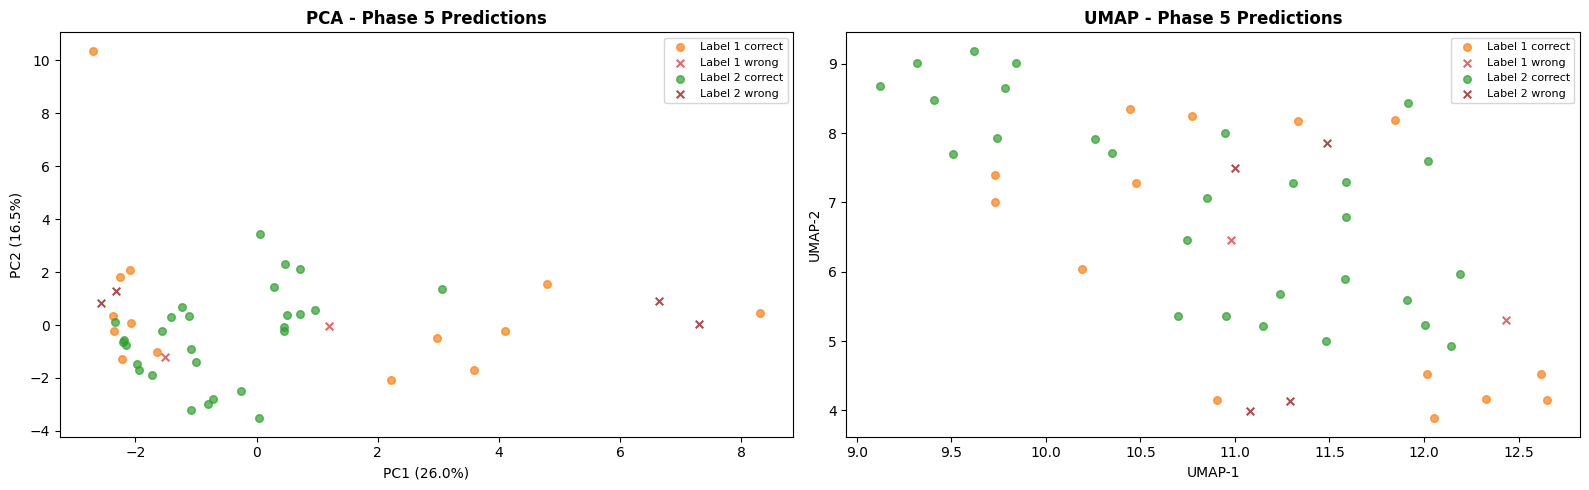

In [14]:
if IS_ENSEMBLE:
    print("Ensemble mode — skipping (see ensemble cell below)")
else:
    p5 = SPEC["phase_5"]
    impchi_k = p5["impchi_k_per_class"]
    impchi_max_feat = p5.get("impchi_max_features", 15000)
    # Support both old ("impchi_ngram_max") and new ("impchi_ngram_range") formats
    if "impchi_ngram_range" in p5:
        impchi_ngram = tuple(p5["impchi_ngram_range"])
    else:
        impchi_ngram = (1, p5.get("impchi_ngram_max", 2))
    impchi_min_df = p5.get("impchi_min_df", 2)
    impchi_sublinear = p5.get("impchi_sublinear", True)
    hgb_p = p5["params"]
    hgb_cw = hgb_p.get("class_weight", "balanced")
    if hgb_cw == "balanced":
        hgb_cw_sklearn = "balanced"
        hgb_cw_lgbm = "balanced"
    elif hgb_cw in ("none", None):
        hgb_cw_sklearn = None
        hgb_cw_lgbm = None
    else:
        hgb_cw_sklearn = hgb_cw
        hgb_cw_lgbm = hgb_cw

    P5_MODEL = p5.get("model", "HistGradientBoostingClassifier")
    P5_VOTING = p5.get("voting", False)

    tr_12_mask = np.isin(y_tr_full, [1, 2])
    tr_12_global = train_idx[tr_12_mask]
    val_p5_global = val_idx[remaining]

    y_tr_p5 = all_labels[tr_12_global]
    y_val_p5 = y_val_full[remaining]

    X_tr_chi, X_val_chi, _, _ = build_impchi(
        texts_clean[tr_12_global], texts_clean[val_p5_global], y_tr_p5, impchi_k,
        impchi_max_feat=impchi_max_feat, impchi_ngram=impchi_ngram,
        impchi_min_df=impchi_min_df, impchi_sublinear=impchi_sublinear)

    # Stylometric subset selection
    stylo_subset = p5.get("stylo_subset", "all_30")
    stylo_cols = STYLO_GROUPS.get(stylo_subset, list(range(29)))
    print(f"Stylo subset: {stylo_subset} ({len(stylo_cols)} features)")

    scaler_p5 = StandardScaler()
    X_tr_stylo = csr_matrix(scaler_p5.fit_transform(stylo_all[tr_12_global][:, stylo_cols]))
    X_val_stylo = csr_matrix(scaler_p5.transform(stylo_all[val_p5_global][:, stylo_cols]))

    X_tr_p5 = hstack([X_tr_chi, X_tr_stylo]).toarray()
    X_val_p5 = hstack([X_val_chi, X_val_stylo]).toarray()

    print(f"Phase 5 features: {X_tr_p5.shape[1]} (ImpCHI + {len(stylo_cols)} stylo)")
    print(f"Phase 5 train: {len(y_tr_p5)} | val: {len(y_val_p5)}")
    print(f"Phase 5 model: {P5_MODEL}, voting={P5_VOTING}")

    # ── Helper to build a Phase-5 model with given params ─────────
    def make_p5_model(lr_override=None, l2_override=None):
        lr = lr_override if lr_override is not None else hgb_p["learning_rate"]
        l2 = l2_override if l2_override is not None else hgb_p["l2_regularization"]
        if P5_MODEL == "LGBMClassifier":
            assert HAS_LGBM, "lightgbm is required for this submission"
            return LGBMClassifier(
                n_estimators=hgb_p["max_iter"], max_depth=hgb_p["max_depth"],
                learning_rate=lr, num_leaves=hgb_p["max_leaf_nodes"],
                min_child_samples=hgb_p["min_samples_leaf"],
                reg_lambda=l2,
                class_weight=hgb_cw_lgbm, random_state=SEED, verbose=-1)
        else:
            return HistGradientBoostingClassifier(
                max_iter=hgb_p["max_iter"], max_depth=hgb_p["max_depth"],
                learning_rate=lr, max_leaf_nodes=hgb_p["max_leaf_nodes"],
                min_samples_leaf=hgb_p["min_samples_leaf"],
                l2_regularization=l2,
                class_weight=hgb_cw_sklearn, random_state=SEED)

    # Train main model
    m5 = make_p5_model()
    m5.fit(X_tr_p5, y_tr_p5)
    all_p5_preds = [m5.predict(X_val_p5)]

    # Train v2/v3 if voting
    if P5_VOTING:
        for vname in ["v2", "v3"]:
            vp = p5.get(f"{vname}_params")
            if vp:
                mv = make_p5_model(
                    lr_override=vp.get("learning_rate"),
                    l2_override=vp.get("l2_regularization"))
                mv.fit(X_tr_p5, y_tr_p5)
                all_p5_preds.append(mv.predict(X_val_p5))

    if len(all_p5_preds) > 1:
        pred_p5 = majority_vote(all_p5_preds)
        print(f"  Phase 5 voting: {len(all_p5_preds)} models")
    else:
        pred_p5 = all_p5_preds[0]

    f1_p5 = f1_score(y_val_p5, pred_p5, average="macro")
    print(f"\nPhase 5 - F1 macro: {f1_p5:.4f}")

    final_pred[remaining] = pred_p5
    if (final_pred == -1).any():
        final_pred[final_pred == -1] = 1

    # ── Confusion matrix ──────────────────────────────────────────
    plot_cm(y_val_p5, pred_p5, [1, 2], "Phase 5 - Label 1 vs Label 2")

    # ── PCA/UMAP - true labels ───────────────────────────────────
    plot_pca_umap(csr_matrix(X_val_p5), y_val_p5, [1, 2], "Phase 5 - True Labels",
                  colors={1: "tab:orange", 2: "tab:green"})

    # ── PCA/UMAP - correct vs wrong (4 categories) ───────────────
    cat = np.array([""] * len(y_val_p5), dtype=object)
    cat[(y_val_p5==1) & (pred_p5==1)] = "Label 1 correct"
    cat[(y_val_p5==1) & (pred_p5!=1)] = "Label 1 wrong"
    cat[(y_val_p5==2) & (pred_p5==2)] = "Label 2 correct"
    cat[(y_val_p5==2) & (pred_p5!=2)] = "Label 2 wrong"

    cat_order = ["Label 1 correct", "Label 1 wrong", "Label 2 correct", "Label 2 wrong"]
    cat_colors = {"Label 1 correct":"tab:orange", "Label 1 wrong":"tab:red",
                  "Label 2 correct":"tab:green", "Label 2 wrong":"darkred"}

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    pca5 = PCA(n_components=2, random_state=SEED)
    cp = pca5.fit_transform(X_val_p5); var = pca5.explained_variance_ratio_
    for c_name in cat_order:
        m = cat == c_name
        if m.sum() > 0:
            axes[0].scatter(cp[m,0], cp[m,1], label=c_name, color=cat_colors[c_name],
                            alpha=0.7, s=30, marker="o" if "correct" in c_name else "x")
    axes[0].set_xlabel(f"PC1 ({var[0]*100:.1f}%)"); axes[0].set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
    axes[0].set_title("PCA - Phase 5 Predictions", fontweight="bold"); axes[0].legend(fontsize=8)

    red5 = umap.UMAP(n_components=2, random_state=SEED, n_neighbors=15, min_dist=0.1)
    cu = red5.fit_transform(X_val_p5)
    for c_name in cat_order:
        m = cat == c_name
        if m.sum() > 0:
            axes[1].scatter(cu[m,0], cu[m,1], label=c_name, color=cat_colors[c_name],
                            alpha=0.7, s=30, marker="o" if "correct" in c_name else "x")
    axes[1].set_xlabel("UMAP-1"); axes[1].set_ylabel("UMAP-2")
    axes[1].set_title("UMAP - Phase 5 Predictions", fontweight="bold"); axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()




### 4h-bis. Ensemble Pipeline

When **IS_ENSEMBLE** is True, this cell runs each member pipeline and combines predictions.


In [15]:
if IS_ENSEMBLE:
    # ══════════════════════════════════════════════════════════
    # Helper: run a FULL 5-phase pipeline for a single spec
    # ══════════════════════════════════════════════════════════
    def run_pipeline_val(spec):
        """Run full pipeline on val split, return prediction array (len = len(val_idx))."""
        _p14 = spec["phases_1_to_4"]
        _tp = _p14["tfidf"]
        _pp = _p14["params"]
        _voting = _p14.get("voting", False)

        _tfidf = TfidfVectorizer(
            max_features=_tp["max_features"],
            ngram_range=tuple(_tp["ngram_range"]),
            sublinear_tf=_tp["sublinear_tf"],
            min_df=_tp["min_df"],
            strip_accents="unicode", analyzer="word")
        _Xtr = _tfidf.fit_transform(texts_clean[train_idx])
        _Xval = _tfidf.transform(texts_clean[val_idx])
        _ytr = all_labels[train_idx]

        def _get_C(ph, view="main"):
            if view == "main":
                return _pp.get(f"C_p{ph}", _pp.get("C"))
            return _pp.get(f"C_{view}_p{ph}", _pp.get(f"C_{view}"))

        def _mk(C):
            cw = _pp.get("class_weight", "balanced")
            return LinearSVC(C=C, max_iter=_pp.get("max_iter", 3000),
                             class_weight=cw, random_state=SEED)

        def _tp_phase(ph, Xtr, ytr, Xte):
            views = ["main"]
            if _voting:
                for v in ["v2", "v3"]:
                    if _get_C(ph, v) is not None:
                        views.append(v)
            preds = [_mk(_get_C(ph, v)).fit(Xtr, ytr).predict(Xte) for v in views]
            return majority_vote(preds) if len(preds) > 1 else preds[0]

        _final = np.full(len(val_idx), -1, dtype=int)

        # Phase 1
        _p1 = _tp_phase(1, _Xtr, (_ytr!=0).astype(int), _Xval)
        _final[_p1==0] = 0; _ai = np.where(_p1==1)[0]

        # Phase 2
        _am = _ytr != 0
        _p2 = _tp_phase(2, _Xtr[_am], (_ytr[_am]==4).astype(int), _Xval[_ai])
        _final[_ai[_p2==1]] = 4; _rem = _ai[_p2!=1]

        # Phase 3
        _m3 = np.isin(_ytr, [1,2,3,5])
        _p3 = _tp_phase(3, _Xtr[_m3], (_ytr[_m3]==3).astype(int), _Xval[_rem])
        _final[_rem[_p3==1]] = 3; _rem = _rem[_p3!=1]

        # Phase 4
        _m4 = np.isin(_ytr, [1,2,5])
        _p4 = _tp_phase(4, _Xtr[_m4], (_ytr[_m4]==5).astype(int), _Xval[_rem])
        _final[_rem[_p4==1]] = 5; _rem = _rem[_p4!=1]

        # Phase 5
        _p5 = spec["phase_5"]
        _p5m = _p5.get("model", "HistGradientBoostingClassifier")
        _p5v = _p5.get("voting", False)
        _hp = _p5["params"]
        _cw = _hp.get("class_weight", "balanced")
        _cw_sk = "balanced" if _cw == "balanced" else (None if _cw in ("none", None) else _cw)
        _cw_lg = _cw_sk
        _ik = _p5["impchi_k_per_class"]
        _imf = _p5.get("impchi_max_features", 15000)
        _ing = tuple(_p5["impchi_ngram_range"]) if "impchi_ngram_range" in _p5 else (1, _p5.get("impchi_ngram_max", 2))
        _imd = _p5.get("impchi_min_df", 2)
        _isub = _p5.get("impchi_sublinear", True)
        _ssub = _p5.get("stylo_subset", "all_30")
        _scols = STYLO_GROUPS.get(_ssub, list(range(29)))

        _tr12 = np.isin(_ytr, [1,2])
        _tr12g = train_idx[_tr12]
        _valg = val_idx[_rem]
        _ytr5 = all_labels[_tr12g]

        _Xchi_tr, _Xchi_val, _, _ = build_impchi(
            texts_clean[_tr12g], texts_clean[_valg], _ytr5, _ik,
            impchi_max_feat=_imf, impchi_ngram=_ing,
            impchi_min_df=_imd, impchi_sublinear=_isub)

        _sc = StandardScaler()
        _Xsty_tr = csr_matrix(_sc.fit_transform(stylo_all[_tr12g][:, _scols]))
        _Xsty_val = csr_matrix(_sc.transform(stylo_all[_valg][:, _scols]))
        _X5tr = hstack([_Xchi_tr, _Xsty_tr]).toarray()
        _X5val = hstack([_Xchi_val, _Xsty_val]).toarray()

        def _mk5(lr_o=None, l2_o=None):
            lr = lr_o if lr_o is not None else _hp["learning_rate"]
            l2 = l2_o if l2_o is not None else _hp["l2_regularization"]
            if _p5m == "LGBMClassifier":
                return LGBMClassifier(
                    n_estimators=_hp["max_iter"], max_depth=_hp["max_depth"],
                    learning_rate=lr, num_leaves=_hp["max_leaf_nodes"],
                    min_child_samples=_hp["min_samples_leaf"],
                    reg_lambda=l2, class_weight=_cw_lg, random_state=SEED, verbose=-1)
            return HistGradientBoostingClassifier(
                max_iter=_hp["max_iter"], max_depth=_hp["max_depth"],
                learning_rate=lr, max_leaf_nodes=_hp["max_leaf_nodes"],
                min_samples_leaf=_hp["min_samples_leaf"],
                l2_regularization=l2, class_weight=_cw_sk, random_state=SEED)

        _m5 = _mk5(); _m5.fit(_X5tr, _ytr5)
        _p5preds = [_m5.predict(_X5val)]
        if _p5v:
            for _vn in ["v2", "v3"]:
                _vp = _p5.get(f"{_vn}_params")
                if _vp:
                    _mv = _mk5(_vp.get("learning_rate"), _vp.get("l2_regularization"))
                    _mv.fit(_X5tr, _ytr5)
                    _p5preds.append(_mv.predict(_X5val))
        _pred5 = majority_vote(_p5preds) if len(_p5preds) > 1 else _p5preds[0]
        _final[_rem] = _pred5
        if (_final == -1).any():
            _final[_final == -1] = 1
        return _final

    # ── Run each member pipeline ──────────────────────────────
    member_preds = {}
    for mname in ENSEMBLE_MEMBERS:
        print(f"Running {mname}...")
        member_preds[mname] = run_pipeline_val(MEMBER_SPECS[mname])
        _f1 = f1_score(y_val_full, member_preds[mname], average="macro")
        print(f"  {mname} standalone F1: {_f1:.4f}")

    # ── Combine predictions ───────────────────────────────────
    if ENSEMBLE_TYPE == "priority_vote":
        names = ENSEMBLE_MEMBERS
        pa, pb = member_preds[names[0]], member_preds[names[1]]
        priority = member_preds[ENSEMBLE_PRIORITY]
        final_pred = np.where(pa == pb, pa, priority)
        agree_pct = (pa == pb).mean() * 100
        print(f"\nAgreement: {agree_pct:.1f}%  |  Disagreements resolved by {ENSEMBLE_PRIORITY}")

    elif ENSEMBLE_TYPE == "majority_vote":
        all_preds = [member_preds[m] for m in ENSEMBLE_MEMBERS]
        final_pred = majority_vote(all_preds)
        agree_all = np.all(np.stack(all_preds) == all_preds[0], axis=0).mean() * 100
        print(f"\nFull agreement: {agree_all:.1f}%")

    print(f"Ensemble F1: {f1_score(y_val_full, final_pred, average='macro'):.4f}")
else:
    print("Single-pipeline mode — ensemble cell skipped")



Single-pipeline mode — ensemble cell skipped


## 4i. End-to-End Evaluation


  END-TO-END RESULTS

  Phase 1 (Human vs AI)      : 0.9978
  Phase 2 (4 vs 1,2,3,5)    : 1.0000
  Phase 3 (3 vs 1,2,5)      : 1.0000
  Phase 4 (5 vs 1,2)        : 1.0000
  Phase 5 (1 vs 2)          : 0.8634

  End-to-End F1 macro       : 0.9529

  Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       304
           1       0.78      0.88      0.82        16
           2       0.93      0.88      0.90        32
           3       1.00      1.00      1.00        16
           4       1.00      1.00      1.00        48
           5       1.00      0.98      0.99        64

    accuracy                           0.99       480
   macro avg       0.95      0.96      0.95       480
weighted avg       0.99      0.99      0.99       480



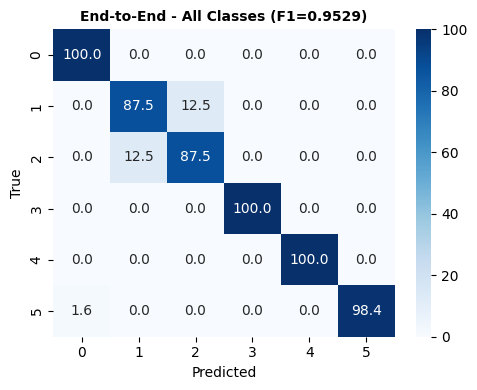

In [16]:
f1_e2e = f1_score(y_val_full, final_pred, average="macro")

print("=" * 60)
print("  END-TO-END RESULTS")
print("=" * 60)

if not IS_ENSEMBLE:
    print(f"\n  Phase 1 (Human vs AI)      : {f1_p1:.4f}")
    print(f"  Phase 2 (4 vs 1,2,3,5)    : {f1_p2:.4f}")
    print(f"  Phase 3 (3 vs 1,2,5)      : {f1_p3:.4f}")
    print(f"  Phase 4 (5 vs 1,2)        : {f1_p4:.4f}")
    print(f"  Phase 5 (1 vs 2)          : {f1_p5:.4f}")
else:
    print(f"\n  Ensemble type: {ENSEMBLE_TYPE}")
    print(f"  Members: {', '.join(ENSEMBLE_MEMBERS)}")

print(f"\n  End-to-End F1 macro       : {f1_e2e:.4f}")
print("\n  Classification Report:")
print(classification_report(y_val_full, final_pred))

plot_cm(y_val_full, final_pred, [0, 1, 2, 3, 4, 5],
        f"End-to-End - All Classes (F1={f1_e2e:.4f})")



## 5. Test Prediction & Submission

Re-train on the **full** training set and predict `test.csv`.
Seeds are reset to ensure exact reproducibility of the submission.


In [17]:
# ── Reset seeds for reproducibility ──────────────────────────
random.seed(SEED)
np.random.seed(SEED)
os.environ["PYTHONHASHSEED"] = str(SEED)

df_test = pd.read_csv("test.csv")
print(f"Test set: {len(df_test)} rows")
df_test["text_clean"] = df_test["TEXT"].apply(clean_text_none)

print("Extracting test stylometric features ")
test_stylo = pd.DataFrame(df_test["TEXT"].apply(extract_stylometric).tolist()).values.astype(float)

if df_test.columns[0] in ["", "Unnamed: 0"]:
    test_ids = df_test.iloc[:, 0].values
else:
    test_ids = df_test.index.values

# ══════════════════════════════════════════════════════════════
# ENSEMBLE TEST PATH
# ══════════════════════════════════════════════════════════════
if IS_ENSEMBLE:
    def run_pipeline_test(spec):
        """Train on ALL data, predict test."""
        _p14 = spec["phases_1_to_4"]
        _tp = _p14["tfidf"]
        _pp = _p14["params"]
        _voting = _p14.get("voting", False)

        _tr_txt = df["text_clean"].values
        _tr_lbl = df["LABEL"].values

        _tfidf = TfidfVectorizer(
            max_features=_tp["max_features"],
            ngram_range=tuple(_tp["ngram_range"]),
            sublinear_tf=_tp["sublinear_tf"],
            min_df=_tp["min_df"],
            strip_accents="unicode", analyzer="word")
        _Xtr = _tfidf.fit_transform(_tr_txt)
        _Xte = _tfidf.transform(df_test["text_clean"].values)

        def _get_C(ph, view="main"):
            if view == "main":
                return _pp.get(f"C_p{ph}", _pp.get("C"))
            return _pp.get(f"C_{view}_p{ph}", _pp.get(f"C_{view}"))

        def _mk(C):
            cw = _pp.get("class_weight", "balanced")
            return LinearSVC(C=C, max_iter=_pp.get("max_iter", 3000),
                             class_weight=cw, random_state=SEED)

        def _tp_phase(ph, Xtr, ytr, Xte):
            views = ["main"]
            if _voting:
                for v in ["v2", "v3"]:
                    if _get_C(ph, v) is not None:
                        views.append(v)
            preds = [_mk(_get_C(ph, v)).fit(Xtr, ytr).predict(Xte) for v in views]
            return majority_vote(preds) if len(preds) > 1 else preds[0]

        n = len(df_test); _tp_arr = np.full(n, -1, dtype=int)

        # Phase 1
        _p1 = _tp_phase(1, _Xtr, (_tr_lbl!=0).astype(int), _Xte)
        _tp_arr[_p1==0] = 0; _ai = np.where(_p1==1)[0]

        # Phase 2
        _am = _tr_lbl != 0
        _p2 = _tp_phase(2, _Xtr[_am], (_tr_lbl[_am]==4).astype(int), _Xte[_ai])
        _tp_arr[_ai[_p2==1]] = 4; _rem = _ai[_p2!=1]

        # Phase 3
        _m3 = np.isin(_tr_lbl, [1,2,3,5])
        _p3 = _tp_phase(3, _Xtr[_m3], (_tr_lbl[_m3]==3).astype(int), _Xte[_rem])
        _tp_arr[_rem[_p3==1]] = 3; _rem = _rem[_p3!=1]

        # Phase 4
        _m4 = np.isin(_tr_lbl, [1,2,5])
        _p4 = _tp_phase(4, _Xtr[_m4], (_tr_lbl[_m4]==5).astype(int), _Xte[_rem])
        _tp_arr[_rem[_p4==1]] = 5; _rem = _rem[_p4!=1]

        # Phase 5
        _p5 = spec["phase_5"]
        _p5m = _p5.get("model", "HistGradientBoostingClassifier")
        _p5v = _p5.get("voting", False)
        _hp = _p5["params"]
        _cw = _hp.get("class_weight", "balanced")
        _cw_sk = "balanced" if _cw == "balanced" else (None if _cw in ("none", None) else _cw)
        _cw_lg = _cw_sk
        _ik = _p5["impchi_k_per_class"]
        _imf = _p5.get("impchi_max_features", 15000)
        _ing = tuple(_p5["impchi_ngram_range"]) if "impchi_ngram_range" in _p5 else (1, _p5.get("impchi_ngram_max", 2))
        _imd = _p5.get("impchi_min_df", 2)
        _isub = _p5.get("impchi_sublinear", True)
        _ssub = _p5.get("stylo_subset", "all_30")
        _scols = STYLO_GROUPS.get(_ssub, list(range(29)))

        _m12 = np.isin(_tr_lbl, [1,2])
        _t12 = _tr_txt[_m12]; _l12 = _tr_lbl[_m12]

        _tf5 = TfidfVectorizer(max_features=_imf, ngram_range=_ing,
                               sublinear_tf=_isub, min_df=_imd,
                               strip_accents="unicode", analyzer="word")
        _Xc = _tf5.fit_transform(_t12)
        _Xct = _tf5.transform(df_test["text_clean"].values[_rem])
        _sel = set()
        for cls in np.unique(_l12):
            sc, _ = chi2(_Xc, (_l12==cls).astype(int))
            _sel.update(np.argsort(sc)[-_ik:])
        _s = sorted(_sel)
        _Xcs = _Xc[:, _s]; _Xcts = _Xct[:, _s]
        _sc5 = StandardScaler()
        _Xs = csr_matrix(_sc5.fit_transform(stylo_all[_m12][:, _scols]))
        _Xst = csr_matrix(_sc5.transform(test_stylo[_rem][:, _scols]))
        _X5 = hstack([_Xcs, _Xs]).toarray()
        _Xt5 = hstack([_Xcts, _Xst]).toarray()

        def _mk5(lr_o=None, l2_o=None):
            lr = lr_o if lr_o is not None else _hp["learning_rate"]
            l2 = l2_o if l2_o is not None else _hp["l2_regularization"]
            if _p5m == "LGBMClassifier":
                return LGBMClassifier(
                    n_estimators=_hp["max_iter"], max_depth=_hp["max_depth"],
                    learning_rate=lr, num_leaves=_hp["max_leaf_nodes"],
                    min_child_samples=_hp["min_samples_leaf"],
                    reg_lambda=l2, class_weight=_cw_lg, random_state=SEED, verbose=-1)
            return HistGradientBoostingClassifier(
                max_iter=_hp["max_iter"], max_depth=_hp["max_depth"],
                learning_rate=lr, max_leaf_nodes=_hp["max_leaf_nodes"],
                min_samples_leaf=_hp["min_samples_leaf"],
                l2_regularization=l2, class_weight=_cw_sk, random_state=SEED)

        _m5 = _mk5(); _m5.fit(_X5, _l12)
        _p5preds = [_m5.predict(_Xt5)]
        if _p5v:
            for _vn in ["v2", "v3"]:
                _vp = _p5.get(f"{_vn}_params")
                if _vp:
                    _mv = _mk5(_vp.get("learning_rate"), _vp.get("l2_regularization"))
                    _mv.fit(_X5, _l12)
                    _p5preds.append(_mv.predict(_Xt5))
        _pred5 = majority_vote(_p5preds) if len(_p5preds) > 1 else _p5preds[0]
        _tp_arr[_rem] = _pred5
        if (_tp_arr == -1).any():
            _tp_arr[_tp_arr == -1] = 1
        return _tp_arr

    # Run each member
    member_test_preds = {}
    for mname in ENSEMBLE_MEMBERS:
        print(f"Test - Running {mname}...")
        member_test_preds[mname] = run_pipeline_test(MEMBER_SPECS[mname])

    # Combine
    if ENSEMBLE_TYPE == "priority_vote":
        names = ENSEMBLE_MEMBERS
        pa, pb = member_test_preds[names[0]], member_test_preds[names[1]]
        priority = member_test_preds[ENSEMBLE_PRIORITY]
        tp = np.where(pa == pb, pa, priority)
    elif ENSEMBLE_TYPE == "majority_vote":
        all_preds = [member_test_preds[m] for m in ENSEMBLE_MEMBERS]
        tp = majority_vote(all_preds)

    os.makedirs("submissions", exist_ok=True)
    sub_df = pd.DataFrame({"ID": test_ids, "LABEL": tp})
    csv_path = f"submissions/{sub_key}.csv"
    sub_df.to_csv(csv_path, index=False)
    print(f"\nSaved: {csv_path}")

# ══════════════════════════════════════════════════════════════
# SINGLE-PIPELINE TEST PATH (original code)
# ══════════════════════════════════════════════════════════════
else:
    tr_txt = df["text_clean"].values; tr_lbl = df["LABEL"].values

    tfidf_f = TfidfVectorizer(max_features=tfidf_p["max_features"],
        ngram_range=tuple(tfidf_p["ngram_range"]), sublinear_tf=tfidf_p["sublinear_tf"],
        min_df=tfidf_p["min_df"], strip_accents="unicode", analyzer="word")
    X_tr_f = tfidf_f.fit_transform(tr_txt)
    X_te_f = tfidf_f.transform(df_test["text_clean"].values)

    def svc_f(C_val):
        cw = p14_params.get("class_weight", "balanced")
        return LinearSVC(C=C_val, max_iter=p14_params.get("max_iter", 3000),
                         class_weight=cw, random_state=SEED)

    def train_predict_test_phase(phase_num, X_tr, y_tr, X_te):
        views = ["main"]
        if P14_VOTING:
            for v in ["v2", "v3"]:
                if get_svc_C(phase_num, v) is not None:
                    views.append(v)
        preds = []
        for view in views:
            C_val = get_svc_C(phase_num, view)
            m = svc_f(C_val)
            m.fit(X_tr, y_tr)
            preds.append(m.predict(X_te))
        return majority_vote(preds) if len(preds) > 1 else preds[0]

    n_te = len(df_test); tp = np.full(n_te, -1, dtype=int)

    print("\nPhase 1 ")
    p1 = train_predict_test_phase(1, X_tr_f, (tr_lbl!=0).astype(int), X_te_f)
    tp[p1==0]=0; ai=np.where(p1==1)[0]
    print(f"  Human:{(p1==0).sum()} AI:{(p1==1).sum()}")

    print("Phase 2 ")
    am=tr_lbl!=0
    p2 = train_predict_test_phase(2, X_tr_f[am], (tr_lbl[am]==4).astype(int), X_te_f[ai])
    i4=p2==1; tp[ai[i4]]=4; rem=ai[~i4]
    print(f"  4:{i4.sum()} rem:{(~i4).sum()}")

    print("Phase 3 ")
    m3m=np.isin(tr_lbl,[1,2,3,5])
    p3 = train_predict_test_phase(3, X_tr_f[m3m], (tr_lbl[m3m]==3).astype(int), X_te_f[rem])
    i3=p3==1; tp[rem[i3]]=3; rem=rem[~i3]
    print(f"  3:{i3.sum()} rem:{(~i3).sum()}")

    print("Phase 4 ")
    m4m=np.isin(tr_lbl,[1,2,5])
    p4 = train_predict_test_phase(4, X_tr_f[m4m], (tr_lbl[m4m]==5).astype(int), X_te_f[rem])
    i5=p4==1; tp[rem[i5]]=5; rem=rem[~i5]
    print(f"  5:{i5.sum()} rem:{(~i5).sum()}")

    print("Phase 5 ")
    p5 = SPEC["phase_5"]
    m12=np.isin(tr_lbl,[1,2]); t12=tr_txt[m12]; l12=tr_lbl[m12]
    tf5=TfidfVectorizer(max_features=impchi_max_feat, ngram_range=impchi_ngram,
                        sublinear_tf=impchi_sublinear,
                        min_df=impchi_min_df, strip_accents="unicode", analyzer="word")
    Xc=tf5.fit_transform(t12); Xct=tf5.transform(df_test["text_clean"].values[rem])
    sel5=set()
    for cls in np.unique(l12):
        sc,_=chi2(Xc,(l12==cls).astype(int)); sel5.update(np.argsort(sc)[-impchi_k:])
    s5=sorted(sel5); Xcs=Xc[:,s5]; Xcts=Xct[:,s5]
    sc5=StandardScaler()
    stylo_cols_test = STYLO_GROUPS.get(p5.get("stylo_subset", "all_30"), list(range(29)))
    Xs=csr_matrix(sc5.fit_transform(stylo_all[m12][:, stylo_cols_test]))
    Xst=csr_matrix(sc5.transform(test_stylo[rem][:, stylo_cols_test]))
    X5=hstack([Xcs,Xs]).toarray(); Xt5=hstack([Xcts,Xst]).toarray()

    m5f = make_p5_model()
    m5f.fit(X5, l12)
    all_p5f_preds = [m5f.predict(Xt5)]

    if P5_VOTING:
        for vname in ["v2", "v3"]:
            vp = p5.get(f"{vname}_params")
            if vp:
                mv = make_p5_model(
                    lr_override=vp.get("learning_rate"),
                    l2_override=vp.get("l2_regularization"))
                mv.fit(X5, l12)
                all_p5f_preds.append(mv.predict(Xt5))

    if len(all_p5f_preds) > 1:
        p5f = majority_vote(all_p5f_preds)
    else:
        p5f = all_p5f_preds[0]

    tp[rem]=p5f
    print(f"  1:{(p5f==1).sum()} 2:{(p5f==2).sum()}")

    if (tp==-1).any(): tp[tp==-1]=1

    os.makedirs("submissions", exist_ok=True)
    sub_df = pd.DataFrame({"ID": test_ids, "LABEL": tp})
    csv_path = f"submissions/{sub_key}.csv"
    sub_df.to_csv(csv_path, index=False)
    print(f"\nSaved: {csv_path}")



Test set: 600 rows
Extracting test stylometric features 

Phase 1 
  Human:380 AI:220
Phase 2 
  4:60 rem:160
Phase 3 
  3:20 rem:140
Phase 4 
  5:80 rem:60
Phase 5 
  1:20 2:40

Saved: submissions/submission4.csv
